In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import pickle
from pathlib import Path

import numpy as np
import numpy.random as npr
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm.notebook import tqdm

from imports import *
from config import dir_config
from src.glm_hmm.cv_utils import cross_validation_split
from src.utils import pmf_utils

In [3]:
processed_dir = Path(dir_config.data.processed)
glm_hmm_dir = processed_dir / "glm_hmm"

behavior_df = pd.read_csv(processed_dir / "processed_all_data_accu_60_all.csv")

MODEL_PATHS = {
    f.stem: f
    for f in glm_hmm_dir.iterdir()
    if f.is_dir() and f.stem.endswith("__global_pooled_cv")
}

desired_order = ["asmHC", "Tremor_OFF", "Brady_OFF", "Tremor_ON", "Brady_ON"]
order_map = {name: i for i, name in enumerate(desired_order)}

In [4]:
# ── helpers ────────────────────────────────────────────────────────────────────

def _enrich_with_color(session_data, behavior_df, config):
    """Add 'color' column from behavior_df to each session DataFrame in the bundle."""
    n_back = config["n_trials_back"]
    enriched = {}
    for session_id, glm_df in session_data.items():
        trial_data = behavior_df[behavior_df["session_id"] == session_id].reset_index(drop=True)
        valid_idx = np.where(trial_data["outcome"] >= 0)[0]
        first_trial = valid_idx[n_back - 1] + 1
        session_df = trial_data.iloc[first_trial:].reset_index(drop=True)
        glm_df = glm_df.copy()
        glm_df["color"] = session_df["color"].values
        enriched[session_id] = glm_df
    return enriched


def _session_fold_expected_choice_prob(model, glm_df, config, fold, k_folds, split):
    """Return expected choice probabilities for one session on one CV fold's split.

    Runs forward-backward on each non-contiguous block separately (preserving the
    Markov structure within each block) then concatenates. Only valid trials kept.
    Returns None if the session has no usable data for this split.
    """
    features = config["model_features"]
    train_idx, test_idx = cross_validation_split(len(glm_df), idx_split=fold, k_folds=k_folds)
    segments = test_idx if split == "test" else train_idx

    seg_posteriors, seg_inputs = [], []
    seg_cols = {k: [] for k in ["choices", "stimulus", "mask", "color"]}

    for seg in segments:
        if len(seg) == 0:
            continue
        s = glm_df.iloc[seg]
        data   = s["choices"].values.astype(int).reshape(-1, 1)
        inputs = s[features].values.astype(np.float64)
        masks  = s["mask"].values.astype(bool).reshape(-1, 1)

        posteriors = model.expected_states(data=data, input=inputs, mask=masks)[0]  # (T_seg, K)
        seg_posteriors.append(posteriors)
        seg_inputs.append(inputs)
        for col in seg_cols:
            seg_cols[col].append(s[col].values)

    if not seg_posteriors:
        return None

    posteriors_all = np.concatenate(seg_posteriors)  # (T_fold, K)
    inputs_all     = np.concatenate(seg_inputs)       # (T_fold, M)

    weights       = -model.observations.params                                          # (K, 1, M)
    weighted_sums = np.einsum("tm,km->tk", inputs_all, weights[:, 0, :])               # (T_fold, K)
    expected_prob = (1 / (1 + np.exp(-weighted_sums)) * posteriors_all).sum(axis=1)    # (T_fold,)

    df = pd.DataFrame({"expected_choice_prob": expected_prob,
                       **{c: np.concatenate(v) for c, v in seg_cols.items()}})
    df = df[df["mask"] == 1].drop(columns="mask")
    return df if len(df) > 0 else None


def _psych_mse(predicted_df, n_samples=10):
    """Psychometric MSE: sum over Equal/Unequal conditions.

    Simulates n_samples choice sequences from expected_choice_prob, fits a
    psychometric curve to each, then measures MSE against the actual curve.
    """
    conditions = [
        (predicted_df["color"] == 0, "Equal"),
        (predicted_df["color"] == 1, "Unequal"),
    ]
    total_mse = 0.0
    for mask, _ in conditions:
        sub = predicted_df[mask]
        if len(sub) == 0:
            continue
        stimulus      = sub["stimulus"].to_numpy() * 100
        choices       = sub["choices"]
        expected_prob = sub["expected_choice_prob"]

        _, _, _, x_model, y_model = pmf_utils.get_psychometric_data(
            {"signed_coherence": stimulus, "choice": choices}
        )

        y_hats = np.empty((n_samples, len(y_model)))
        for i in range(n_samples):
            sim_choices = npr.binomial(1, expected_prob)
            _, _, _, _, y_hat = pmf_utils.get_psychometric_data(
                {"signed_coherence": stimulus, "choice": sim_choices}
            )
            y_hats[i] = y_hat

        total_mse += np.mean((y_hats.mean(axis=0) - y_model) ** 2)

    return total_mse


def parsimonious_k_mse(states, mean_mse, sem_mse):
    """Smallest K whose mean MSE is within 1 SEM of the minimum MSE."""
    best_idx   = int(np.argmin(mean_mse))
    cutoff     = mean_mse[best_idx] + sem_mse[best_idx]
    chosen_idx = next(i for i in range(best_idx + 1) if mean_mse[i] <= cutoff)
    return int(states[chosen_idx]), int(states[best_idx])


def plot_mse_curve(states, test_mean, test_sem, title="", best_k=None, train=None, ax=None):
    if ax is None:
        ax = plt.gca()

    TEST_C, TRAIN_C = "tab:blue", "tab:orange"
    test_line = ax.errorbar(states, test_mean, yerr=test_sem, marker="o", markersize=9,
                            linewidth=2.5, capsize=4, color=TEST_C, label="test")

    if best_k is not None:
        best_idx = np.where(states == best_k)[0][0]
        ax.plot(states[best_idx], test_mean[best_idx], marker="o", markersize=15,
                markerfacecolor="none", markeredgecolor="red", markeredgewidth=2)

    ax.set_xlabel("Number of States", fontsize=20)
    ax.set_ylabel("Test Psych MSE", fontsize=20, color=TEST_C)
    ax.tick_params(labelsize=15)
    ax.tick_params(axis="y", labelcolor=TEST_C)
    ax.spines["top"].set_visible(False)

    handles = [test_line]
    if train is not None:
        train_mean, train_sem = train
        ax2 = ax.twinx()
        train_line = ax2.errorbar(states, train_mean, yerr=train_sem, marker="s", markersize=8,
                                  linewidth=2, linestyle="--", capsize=4, color=TRAIN_C, label="train")
        ax2.set_ylabel("Train Psych MSE", fontsize=20, color=TRAIN_C)
        ax2.tick_params(labelsize=15, axis="y", labelcolor=TRAIN_C)
        ax2.spines["top"].set_visible(False)
        handles.append(train_line)
    else:
        ax.spines["right"].set_visible(False)

    ax.set_xticks(states.astype(int))
    ax.legend(handles=handles, labels=[h.get_label() for h in handles],
              fontsize=12, loc="upper right", frameon=False)
    ax.set_title(title, fontsize=18)

In [5]:
# ── compute psych MSE per (model, group, state, fold) in parallel ───────────────

def _process_group_pkl(model_name, pkl_path, behavior_df, order_map, n_samples=10):
    """Compute test & train psych MSE for every (state, fold) in one group bundle.

    MSE is summed across sessions (matching how 5.21 accumulates per-session MSE),
    then averaged across folds for the final state-selection curve.
    """
    if pkl_path.stat().st_size == 0:
        print(f"  ! skipping empty: {pkl_path}")
        return model_name, pkl_path.stem, None

    with open(pkl_path, "rb") as f:
        bundle = pickle.load(f)

    gpc         = bundle["group_pooled_cv"]
    config      = bundle["config"]
    state_range = np.asarray(gpc["state_range"])
    models_cv   = gpc["models"]   # {n_states: [fold_model_0, fold_model_1, ...]}
    k_folds     = gpc["train_ll"].shape[1]

    session_data = _enrich_with_color(bundle["data"], behavior_df, config)

    test_mse  = np.full((len(state_range), k_folds), np.nan)
    train_mse = np.full((len(state_range), k_folds), np.nan)

    for state_idx, n_states in enumerate(state_range):
        n_states = int(n_states)
        for fold in range(k_folds):
            model = models_cv[n_states][fold]
            for split, arr in (("test", test_mse), ("train", train_mse)):
                total = 0.0
                has_data = False
                for glm_df in session_data.values():
                    pred_df = _session_fold_expected_choice_prob(model, glm_df, config, fold, k_folds, split)
                    if pred_df is not None:
                        total += _psych_mse(pred_df, n_samples=n_samples)
                        has_data = True
                if has_data:
                    arr[state_idx, fold] = total

    return model_name, pkl_path.stem, {"states": state_range, "test_mse": test_mse, "train_mse": train_mse}


pooled_pkls = [
    (model_name, pkl_path)
    for model_name, model_dir in MODEL_PATHS.items()
    for pkl_path in sorted(
        (p for p in model_dir.glob("*.pkl") if not p.stem.endswith("_final") and p.stat().st_size > 0),
        key=lambda p: order_map.get(p.stem, float("inf"))
    )
]

print(f"Running psych MSE CV on {len(pooled_pkls)} (model, group) pairs...")

raw_results = Parallel(n_jobs=-1, verbose=5)(
    delayed(_process_group_pkl)(model_name, pkl_path, behavior_df, order_map)
    for model_name, pkl_path in pooled_pkls
)

Running psych MSE CV on 95 (model, group) pairs...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done  52 out of  95 | elapsed:  3.6min remaining:  2.9min
[Parallel(n_jobs=-1)]: Done  72 out of  95 | elapsed:  4.5min remaining:  1.5min
[Parallel(n_jobs=-1)]: Done  92 out of  95 | elapsed:  5.2min remaining:   10.2s
[Parallel(n_jobs=-1)]: Done  95 out of  95 | elapsed:  5.7min finished


In [6]:
# ── organise results: model_name -> group_name -> {states, test_mse, train_mse} ──

mse_results = {}
for model_name, group_name, data in raw_results:
    if data is None:
        continue
    mse_results.setdefault(model_name, {})[group_name] = data

In [11]:
# ── per-model state selection plots (MSE vs n_states, test + train) ────────────

for model_name, groups in mse_results.items():
    sorted_groups = sorted(groups.keys(), key=lambda g: order_map.get(g, float("inf")))

    # fig, axs = plt.subplots(1, len(sorted_groups), figsize=(12 * len(sorted_groups) // 5 * len(sorted_groups), 6))
    # if len(sorted_groups) == 1:
    #     axs = [axs]


    for idx, group_name in enumerate(sorted_groups):
        d = groups[group_name]
        states    = d["states"]
        test_mean = np.nanmean(d["test_mse"],  axis=1)
        test_sem  = np.nanstd(d["test_mse"],   axis=1) / np.sqrt(np.sum(~np.isnan(d["test_mse"]), axis=1))
        train_mean = np.nanmean(d["train_mse"], axis=1)
        train_sem  = np.nanstd(d["train_mse"],  axis=1) / np.sqrt(np.sum(~np.isnan(d["train_mse"]), axis=1))
        best_k, _ = parsimonious_k_mse(states, test_mean, test_sem)
        d["best_k"] = best_k  # store for downstream use

    #     plot_mse_curve(states, test_mean, test_sem, title=group_name, best_k=best_k,
    #                    train=(train_mean, train_sem), ax=ax[idx])

    # fig.suptitle(model_name, fontsize=20, y=1.05)
    # fig.tight_layout()
    # plt.savefig(MODEL_PATHS[model_name] / "model_selection_psych_mse.png", bbox_inches="tight")
    # plt.show()

## Cross-config comparison

For each pooled-CV model, extract the mean test psych MSE at the parsimonious `best_k`
and compare across configs.

**How to read:**
- **Lower** psych MSE = better (model psychometric curve is closer to the observed one).
- The K label is the chosen state count for that (config, group).
- Use this alongside bits/trial from 5.20 — a config that ranks well on both metrics is the most robust choice.

In [12]:
rows = []
for model_name, groups in mse_results.items():
    config_name = model_name.replace("__global_pooled_cv", "")
    for group_name, d in groups.items():
        states     = d["states"]
        test_mean  = np.nanmean(d["test_mse"], axis=1)
        test_sem   = np.nanstd(d["test_mse"],  axis=1) / np.sqrt(np.sum(~np.isnan(d["test_mse"]), axis=1))
        best_k, _  = parsimonious_k_mse(states, test_mean, test_sem)
        best_idx   = int(np.where(states == best_k)[0][0])
        rows.append(dict(config=config_name, group=group_name,
                         best_k=best_k, mse=test_mean[best_idx], sem=test_sem[best_idx]))

df_cmp = pd.DataFrame(rows)

pivot_mse = df_cmp.pivot(index="config", columns="group", values="mse").reindex(columns=desired_order)
pivot_k   = df_cmp.pivot(index="config", columns="group", values="best_k").reindex(columns=desired_order)
pivot_mse["mean"] = pivot_mse.mean(axis=1)

cell_text = (
    pivot_mse.drop(columns="mean").map(lambda v: f"{v:.4f}")
    + "  (K=" + pivot_k.map(lambda v: str(int(v))) + ")"
)
cell_text["mean"] = pivot_mse["mean"].map(lambda v: f"{v:.4f}")
cell_text = cell_text.sort_values("mean", ascending=True)  # lower MSE = better

print("Pooled CV — test psych MSE at best_k  (lower = better, sorted by mean across groups)\n")
print(cell_text.to_string())
print(f"\nBest overall config: {cell_text.index[0]}  (mean MSE = {cell_text['mean'].iloc[0]})")

Pooled CV — test psych MSE at best_k  (lower = better, sorted by mean across groups)

group                                                                                 asmHC     Tremor_OFF      Brady_OFF      Tremor_ON       Brady_ON    mean
config                                                                                                                                                         
XYZ__tgt_min                                                                  0.3637  (K=5)  0.1986  (K=5)  0.2085  (K=6)  0.2493  (K=5)  0.2036  (K=4)  0.2448
no_standardization_curr_stim_color_prev_choiceXtarget_no_prev_target          0.3828  (K=4)  0.2039  (K=5)  0.2510  (K=5)  0.2688  (K=5)  0.1933  (K=5)  0.2600
XYZ__tgt                                                                      0.3805  (K=6)  0.2199  (K=3)  0.2722  (K=3)  0.2301  (K=6)  0.2200  (K=3)  0.2645
XYZ__coh                                                                      0.4191  (K=5)  0.1937  (K=6)  0.2675

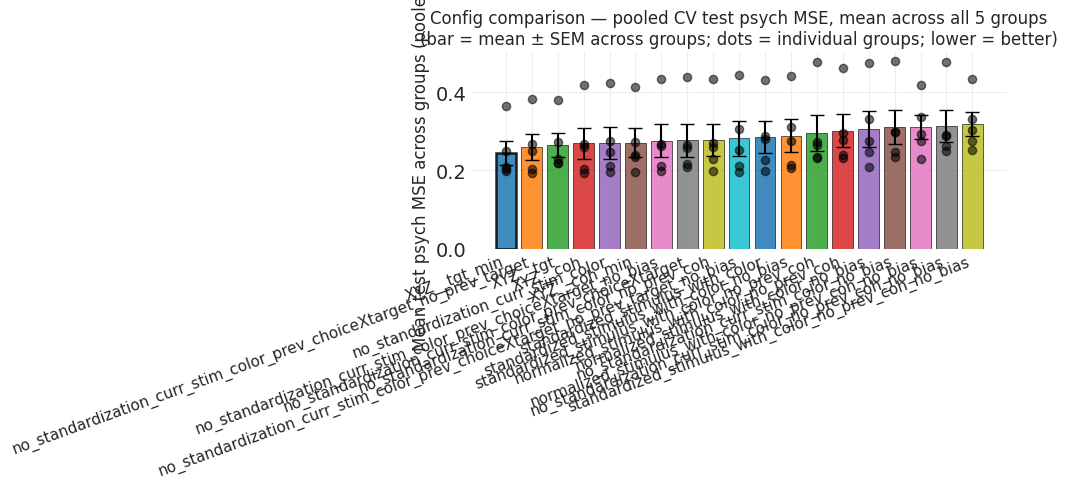

In [13]:
configs_sorted = cell_text.index.tolist()
group_mse      = pivot_mse.drop(columns="mean").reindex(configs_sorted)
means = group_mse.mean(axis=1).values
sems  = group_mse.sem(axis=1).values

config_colors = {c: plt.cm.tab10.colors[i % 10] for i, c in enumerate(configs_sorted)}

fig, ax = plt.subplots(figsize=(10, 5))
for i, config in enumerate(configs_sorted):
    is_best = i == 0
    ax.bar(i, means[i], color=config_colors[config], alpha=0.85,
           edgecolor="black", linewidth=1.8 if is_best else 0.5)
    ax.errorbar(i, means[i], yerr=sems[i], color="black", capsize=5, linewidth=1.5, zorder=5)
    for group in desired_order:
        if group in group_mse.columns:
            ax.scatter(i, group_mse.loc[config, group], color="black", s=35, zorder=6, alpha=0.55)

ax.set_xticks(range(len(configs_sorted)))
ax.set_xticklabels(configs_sorted, rotation=20, ha="right", fontsize=11)
ax.set_ylabel("Mean test psych MSE across groups (pooled CV)", fontsize=12)
ax.set_title(
    "Config comparison — pooled CV test psych MSE, mean across all 5 groups\n"
    "(bar = mean ± SEM across groups; dots = individual groups; lower = better)",
    fontsize=12,
)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(glm_hmm_dir / "cross_config_comparison_psych_mse.png", bbox_inches="tight", dpi=150)
plt.show()

In [10]:
# ── persist results for combined comparison in 5.24 ───────────────────────────
df_cmp.to_csv(glm_hmm_dir / "model_selection_psych_mse_cv.csv", index=False)
pivot_k.to_csv(glm_hmm_dir / "model_selection_best_k_mse.csv")